In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram, cut_tree, leaves_list

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [7]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Distance de Jaccard entre thèmes**

In [8]:
# la distance de Jaccard est calculée entre toutes les paires de lignes :
# 65 thèmes => [65 x (65-1)]/2 paires (=2080)

MT = matrix_themes.T.to_numpy().astype(bool)

dist_jaccard_T = pdist(
    MT, 
    metric="jaccard"
)

**Linkage sur matrice de Jaccard**

In [9]:
LT = linkage(
    dist_jaccard_T, 
    method="average"
)

**Mise en ordre des thèmes selon le dendrogramme**

In [10]:
# array des distances de Jaccard
dist_array = dist_jaccard_T.copy()

# formation en matrice carrée
dist_matrix = squareform(dist_array)

# ordre des thèmes selon le dendrogramme
ordered_idx = leaves_list(LT)
reordered_idx = np.flip(ordered_idx)

# matrice réordonnée
dist_matrix_reordered = dist_matrix[reordered_idx, :][:, reordered_idx]

# avec les noms des thèmes
theme_names_reordered = np.array(the_themes)[reordered_idx]

**Réorganisation des thèmes selon l'ordre issu du dendrogramme**

In [11]:
# on prend "matrix_themes" qui est arrangé par ordre alphabétique
# et on lui applique le fichier "theme_names_reordered"
# qui contient les thèmes dans l'ordre du dendrogramme

matrix_themes_reordered = matrix_themes.loc[:, theme_names_reordered]

In [12]:
# on calcule la matrice des co-occurrences réordonnée
# matrice des thèmes en ligne x matrice des thèmes en colonne

matrix_co_occurrence = matrix_themes_reordered.T @ matrix_themes_reordered

max_val = max(matrix_co_occurrence.max())
min_val = min(matrix_co_occurrence.min())

**Heatmap des co-occurrences réordonnées**

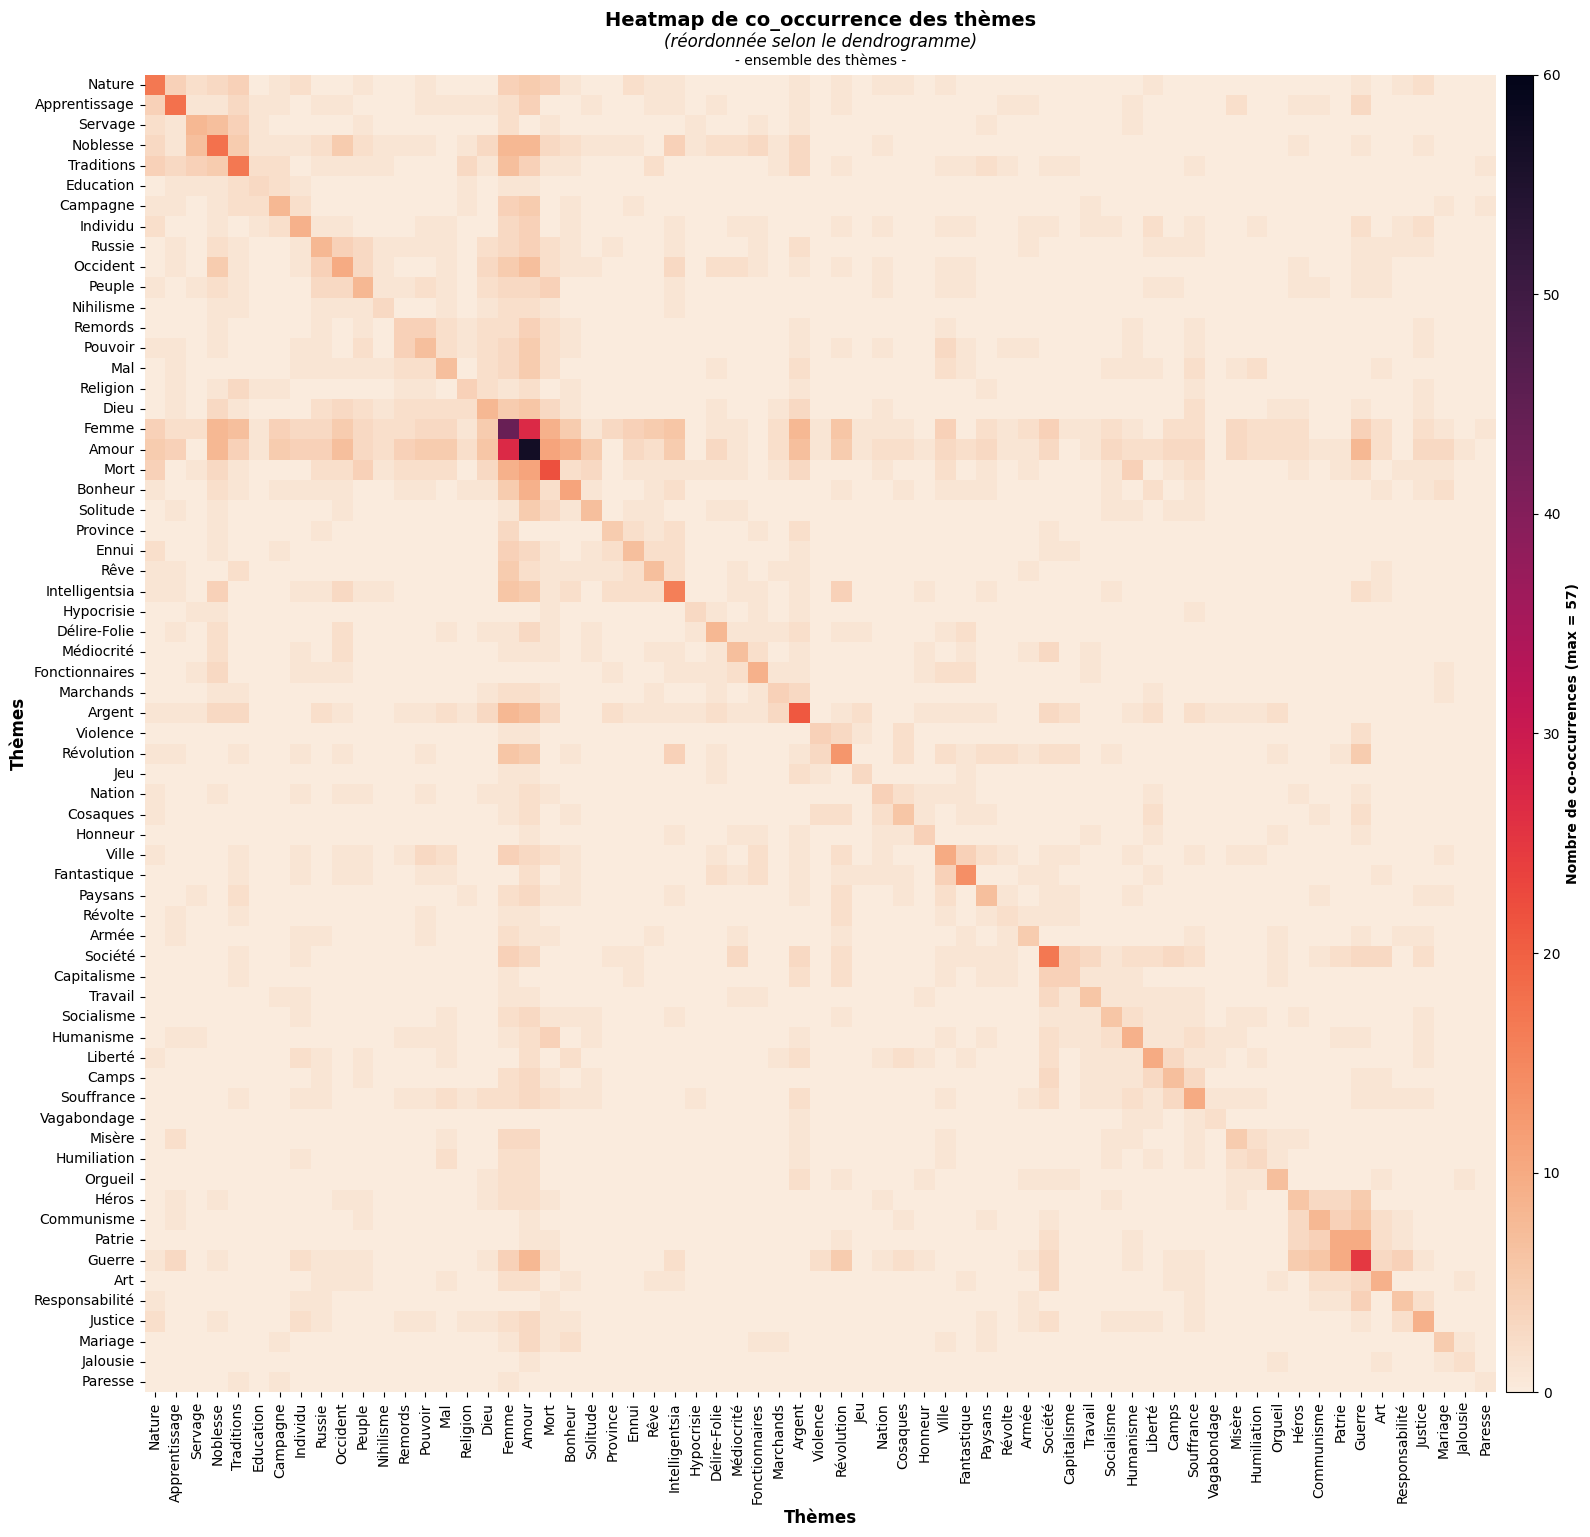

In [13]:

fig, ax = plt.subplots(figsize=(16, 16))

sns.heatmap(
    matrix_co_occurrence,
    cmap="rocket_r",
    cbar=False,
    vmin=min_val,
    vmax=max_val+3,
    ax=ax
)

im = ax.collections[0]

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="2%",   # largeur de la colorbar
    pad=0.10     # distance au graphique
)

cbar = fig.colorbar(
    im,
    cax=cax,
    ticks=np.arange(min_val, max_val+4, 10),
#    extend="min"
)
cbar.set_label(f"Nombre de co-occurrences (max = {max_val})", fontsize=10, fontweight="bold")
cbar.ax.tick_params(labelsize=10)

# labels des thèmes
n = len(theme_names_reordered)

ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)

ax.set_xticklabels(theme_names_reordered, rotation=90, fontsize=10)
ax.set_yticklabels(theme_names_reordered, rotation=0, fontsize=10)

ax.set_xlabel("Thèmes", fontsize=12, fontweight="bold")
ax.set_ylabel("Thèmes", fontsize=12, fontweight="bold")

fig.tight_layout(rect=[0, 0, 1, 0.93]) # réserve de la place au-dessus du graphique

titres(
    fig,
    ax,
    t1="Heatmap de co_occurrence des thèmes", y1=35,
    t2="(réordonnée selon le dendrogramme)", y2=20,
    t3="- ensemble des thèmes -", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_cooccurrence_heatmap_réordonnée_clustering.png", 
    dpi=300, 
    bbox_inches="tight")

plt.show()



In [14]:
# maximum des valeurs en-dehors de la diagonale
matrix_co_occurrence_no_diag = matrix_co_occurrence.copy()

np.fill_diagonal(matrix_co_occurrence_no_diag.values, 0)

max_couple = max(matrix_co_occurrence_no_diag.max())

print(max_couple)

27


In [15]:
# couple de thèmes correspondant
couple_max = matrix_co_occurrence_no_diag.stack().idxmax()

theme1, theme2 = couple_max

print(theme1)
print(theme2)
print(matrix_co_occurrence_no_diag.loc[theme1, theme2])

Femme
Amour
27
